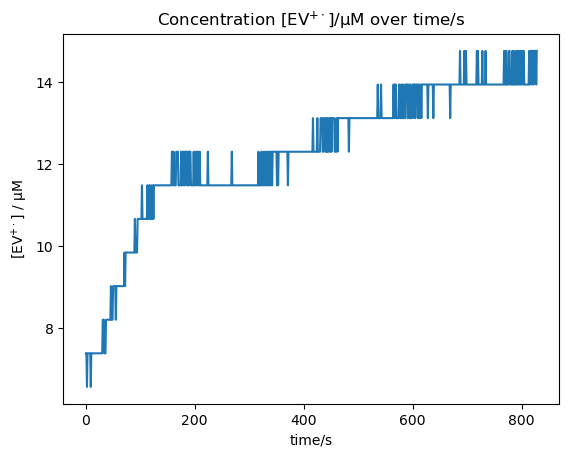

In [24]:
from pathlib import Path
from matplotlib import pyplot as plt
from functions import *

data = './results/OceanOptics/Rubpy_EV_EDTA_Test'

# plotting the concentration of EV+. over time

a = []

start = '16-41-38' # start time, first file to read
read = False

for f in Path(data).glob('*.txt'):
    if f.name[-16:-8] == start:
        read = True # start reading files
    elif read:
        with f.open("r") as file:
            for l in file:
                if l.split("	")[0] == '600.074': # search for EV+. absorbance peak around 600 nm
                    a.append(float(l.split("	")[1]))
                    break

t = list(range(len(a))) # create a time array based on the number of absorbance measurements
c = [beerlambert(a=abs, l=1e-2, e=1.22e6)*1e6 for abs in a] # convert absorbance to concentration in uM using Beer-Lambert law

plt.plot(t, c)
plt.xlabel(r'time/s')
plt.ylabel(r'[EV$^{+\cdot}$] / $\mathrm{\mu}$M')
plt.title(r'Concentration [EV$^{+\cdot}$]/$\mathrm{\mu}$M over time/s')
plt.show()


In [25]:
csol = solprop(cstock=1e-3, valiquot=300e-6, vsol=3e-3)
print(f"concentration of EV in initial solution: {csol*1e6:.2f} μM")

concentration of EV in initial solution: 100.00 μM
